In [3]:
from unstructured.partition.pdf import partition_pdf
import warnings
warnings.filterwarnings('ignore')
import pytesseract

import os
os.environ["TESSERACT_CMD"] = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
os.environ["PATH"] += r";C:\Program Files\Tesseract-OCR"

# Add this line at the top of your file
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
file_path = r"C:\Users\Arnav Agarwal\Desktop\Microsoft Hack\papers\13126-JEE-Main-2025-Question-Paper-with-Solution-23-Jan-Shift-1-PDF.pdf.pdf"

def partition_and_chunk_pdf(file_path):
    """Partitions and chunks a PDF file into manageable pieces. 
    """
    chunks= partition_pdf(
        filename=file_path,
        infer_tables_structure=True,          # Extract tables with structure
        strategy='hi_res',                     # Mandatory to infer tables
        
        extract_image_block_types=["Image"],   # Add 'Table' to list to extract tables as images
        # image_output_dir_path=output_path,    # Directory to save images
        
        extract_image_block_to_payload=True,   # Extract metadata element containing base64 object of the image
                                                # Must when sending the image to LLMs
        
        chunking_strategy="by_title",          # Chunking strategy to use, can be 'by_title', 'basic'
        max_characters=2000,                   # Maximum number of characters per chunk
        combine_text_under_n_chars=500,        # Combine text blocks under this number of characters with previous text block
        new_after_n_chars=6000,                # New chunk after this number of characters. Hard limit.
    )
    return chunks

chunks = partition_and_chunk_pdf(file_path)

In [4]:
a = set()
for chunk in chunks:
    for el in chunk.metadata.orig_elements:
        a.add(el.category)
print(a)

{'NarrativeText', 'ListItem', 'UncategorizedText', 'FigureCaption', 'Image', 'Table', 'Formula', 'Title'}


In [ ]:
def save_texts(chunks):
    """
    Extracts texts from the list of chunks.
    """
    texts = [chunk for chunk in chunks if 'NarrativeText' in str(type(chunk))]

    return texts

In [9]:
def get_image_base64(chunks):
    image_b64 = []
    for chunk in chunks:
        chunk_el = chunk.metadata.orig_elements
        for el in chunk_el:
            if 'Image' in str(type(el)):
                image_b64.append(el.metadata.image_base64)
    return image_b64

images = get_image_base64(chunks)

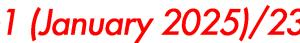

In [ ]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    ## decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # display the image
    display(Image(data=image_data))
    
display_base64_image(images[20])